<a href="https://www.kaggle.com/code/abhishekgodara/santa-s-tree-packing-score-70-990692023?scriptVersionId=288953470" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Optimizing Score: Sum(s_n^2 / n)...
Visualizing N=200 configuration...


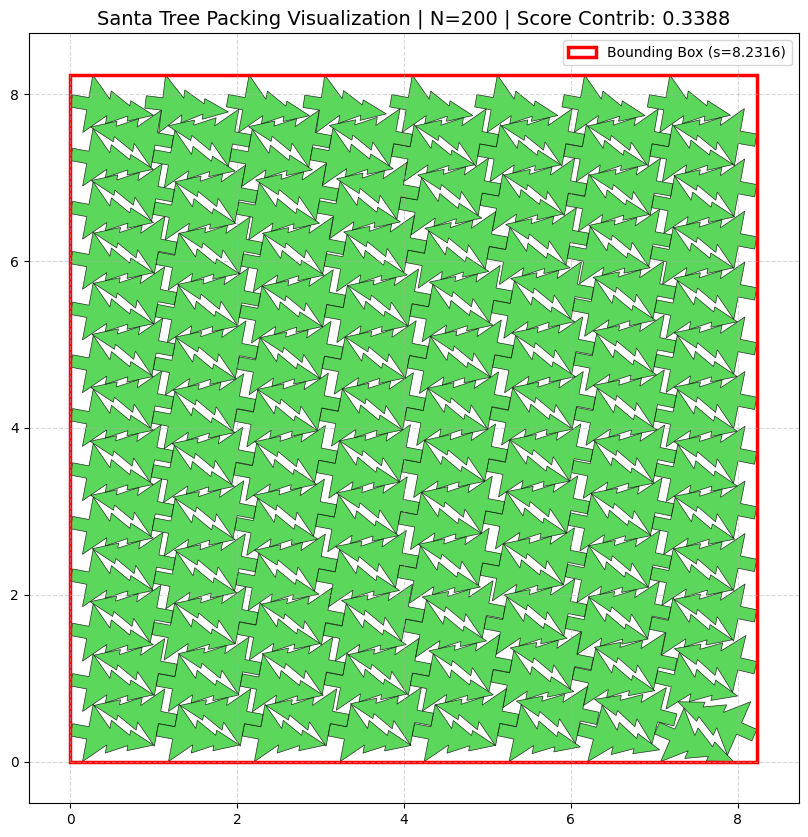

In [1]:
import os, glob
import numpy as np
import pandas as pd
from numba import njit
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mpl_Polygon

# Santa Tree Shape
PX = np.array([0.0, 0.125, 0.0625, 0.2, 0.1, 0.35, 0.075, 0.075, -0.075, -0.075, -0.35, -0.1, -0.2, -0.0625, -0.125], dtype=np.float64)
PY = np.array([0.8, 0.5, 0.5, 0.25, 0.25, 0.0, 0.0, -0.2, -0.2, 0.0, 0.0, 0.25, 0.25, 0.5, 0.5], dtype=np.float64)

@njit(cache=True)
def get_tree_poly(cx, cy, deg):
    a = deg * 0.017453292519943295
    ca, sa = math.cos(a), math.sin(a)
    res = np.empty((15, 2), dtype=np.float64)
    for i in range(15):
        res[i, 0] = (ca * PX[i] - sa * PY[i]) + cx
        res[i, 1] = (sa * PX[i] + ca * PY[i]) + cy
    return res

@njit(cache=True)
def is_overlapping(p1, p2):
    m1x, M1x = np.min(p1[:,0]), np.max(p1[:,0])
    m1y, M1y = np.min(p1[:,1]), np.max(p1[:,1])
    m2x, M2x = np.min(p2[:,0]), np.max(p2[:,0])
    m2y, M2y = np.min(p2[:,1]), np.max(p2[:,1])
    if M1x < m2x or M2x < m1x or M1y < m2y or M2y < m1y: return False

    for poly in (p1, p2):
        for i in range(15):
            p1_pt, p2_pt = poly[i], poly[(i + 1) % 15]
            ax, ay = -(p2_pt[1] - p1_pt[1]), (p2_pt[0] - p1_pt[0])
            min1, max1 = 1e30, -1e30
            for k in range(15):
                dot = p1[k,0]*ax + p1[k,1]*ay
                if dot < min1: min1 = dot
                if dot > max1: max1 = dot
            min2, max2 = 1e30, -1e30
            for k in range(15):
                dot = p2[k,0]*ax + p2[k,1]*ay
                if dot < min2: min2 = dot
                if dot > max2: max2 = dot
            if max1 < min2 or max2 < min1: return False
    return True

@njit(cache=True)
def get_side_fast(xs, ys, ds, n):
    mnx, mxx, mny, mxy = 1e30, -1e30, 1e30, -1e30
    for i in range(n):
        a = ds[i] * 0.017453292519943295
        ca, sa = math.cos(a), math.sin(a)
        for j in range(15):
            tx = (ca * PX[j] - sa * PY[j]) + xs[i]
            ty = (sa * PX[j] + ca * PY[j]) + ys[i]
            if tx < mnx: mnx = tx
            if tx > mxx: mxx = tx
            if ty < mny: mny = ty
            if ty > mxy: mxy = ty
    w, h = mxx - mnx, mxy - mny
    return max(w, h)

@njit(cache=True)
def aggressive_optimize(xs, ys, ds, n):
    curr_side = get_side_fast(xs, ys, ds, n)
    polys = [get_tree_poly(xs[i], ys[i], ds[i]) for i in range(n)]
    move_steps = np.array([0.05, 0.01, 0.002, -0.05, -0.01, -0.002])
    rots = np.array([0.0, 90.0, 180.0, 270.0, 1.0, -1.0])

    for _round in range(2):
        improved = False
        for i in range(n):
            ox, oy, od = xs[i], ys[i], ds[i]
            for dx in move_steps:
                for dy in move_steps:
                    for dr in rots:
                        nx, ny, nd = ox + dx, oy + dy, (od + dr) % 360.0
                        n_poly = get_tree_poly(nx, ny, nd)
                        collision = False
                        for j in range(n):
                            if i == j: continue
                            if is_overlapping(n_poly, polys[j]):
                                collision = True; break
                        if not collision:
                            xs[i], ys[i], ds[i] = nx, ny, nd
                            new_s = get_side_fast(xs, ys, ds, n)
                            if new_s < curr_side - 1e-9:
                                curr_side, polys[i] = new_s, n_poly
                                improved, ox, oy, od = True, nx, ny, nd
                            else:
                                xs[i], ys[i], ds[i] = ox, oy, od
        if not improved: break

    mnx, mny = 1e30, 1e30
    for i in range(n):
        for j in range(15):
            if polys[i][j,0] < mnx: mnx = polys[i][j,0]
            if polys[i][j,1] < mny: mny = polys[i][j,1]
    for i in range(n):
        xs[i] -= mnx
        ys[i] -= mny

def visualize_packing(n, xs, ys, ds):
    """Draws the packing configuration for a given N."""
    side = get_side_fast(xs, ys, ds, n)
    fig, ax = plt.subplots(figsize=(10, 10))
    
    for i in range(n):
        poly_pts = get_tree_poly(xs[i], ys[i], ds[i])
        # Use different shades of green for variety
        color = 'forestgreen' if ds[i] == 0 or ds[i] == 180 else 'limegreen'
        ax.add_patch(mpl_Polygon(poly_pts, closed=True, facecolor=color, edgecolor='black', alpha=0.8, lw=0.5))
    
    # Square bounding box
    ax.add_patch(plt.Rectangle((0, 0), side, side, fill=False, edgecolor='red', lw=2.5, label=f'Bounding Box (s={side:.4f})'))
    
    ax.set_xlim(-0.5, side + 0.5)
    ax.set_ylim(-0.5, side + 0.5)
    ax.set_aspect('equal')
    ax.set_title(f"Santa Tree Packing Visualization | N={n} | Score Contrib: {side**2/n:.4f}", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def load_all_best():
    files = glob.glob('/kaggle/input/*/*.csv')
    if not files: return None
    configs = {}
    for f in files:
        try:
            df = pd.read_csv(f).set_index('id')
            for c in ['x','y','deg']: df[c] = df[c].astype(str).str.replace('s','').astype(float)
            for n in range(1, 201):
                ids = [f"{n:03d}_{i}" for i in range(n)]
                if all(idx in df.index for idx in ids):
                    sub = df.loc[ids].copy()
                    side = get_side_fast(sub.x.values, sub.y.values, sub.deg.values, n)
                    if n not in configs or side < configs[n][0]:
                        configs[n] = (side, sub)
        except: continue
    return {k: v[1] for k, v in configs.items()}

# Execution logic
configs = load_all_best()
if not configs:
    print("No input files found. Please check paths.")
else:
    final_x, final_y, final_d = np.zeros(20100), np.zeros(20100), np.zeros(20100)
    print("Optimizing Score: Sum(s_n^2 / n)...")

    # Optimization Loop
    for n in range(200, 0, -1):
        idx = n * (n - 1) // 2
        cur_x, cur_y, cur_d = configs[n]['x'].values, configs[n]['y'].values, configs[n]['deg'].values
        
        aggressive_optimize(cur_x, cur_y, cur_d, n)
        
        # Visualize N=200 specifically
        if n == 200:
            print("Visualizing N=200 configuration...")
            visualize_packing(n, cur_x, cur_y, cur_d)
        
        final_x[idx:idx+n], final_y[idx:idx+n], final_d[idx:idx+n] = cur_x, cur_y, cur_d
        
        if n > 1:
            best_s, best_i = 1e30, 0
            for i in range(n):
                tx, ty, td = np.delete(cur_x, i), np.delete(cur_y, i), np.delete(cur_d, i)
                s = get_side_fast(tx, ty, td, n-1)
                if s < best_s: best_s, best_i = s, i
            
            cand = pd.DataFrame({'x': np.delete(cur_x, best_i), 'y': np.delete(cur_y, best_i), 'deg': np.delete(cur_d, best_i)})
            if n-1 in configs:
                if best_s < get_side_fast(configs[n-1]['x'].values, configs[n-1]['y'].values, configs[n-1]['deg'].values, n-1):
                    configs[n-1] = cand
            else: configs[n-1] = cand

    # Create submission
    res = []
    for n in range(1, 201):
        s_idx = n * (n - 1) // 2
        for i in range(n):
            res.append({"id": f"{n:03d}_{i}", "x": f"s{final_x[s_idx+i]:.16f}", "y": f"s{final_y[s_idx+i]:.16f}", "deg": f"s{(final_d[s_idx+i]%360):.16f}"})

    pd.DataFrame(res).to_csv("submission.csv", index=False)

In [2]:
df=pd.read_csv("/kaggle/input/santa-dataset/submission_opt1.csv")
df.head(7)

,id,x,y,deg
0,001_0,s-47.9301466527816,s58.5050450737816,s45
1,002_0,s-4.77111626803882,s0.928559901613278,s23.6293777305521
2,002_1,s-4.46292212879626,s1.45147841622401,s203.629377730552
3,003_0,s0.676583156710393,s1.22043378943992,s155.134051937101
4,003_1,s1.26892421232348,s1.3159747234903,s66.370622269343
5,003_2,s1.16634897979318,s0.823969349432162,s111.125132292893
6,004_0,s0.266333069863332,s0.224004215597681,s336.370620930617


In [3]:
df.to_csv("submission2.csv", index=False)

# UPVOTE the Notebook PLZ